In [1]:
import pandas as pd

files = {
    "main": "psych-ther-ann-rep-csv-2024-25-main2.csv",
    "employment": "psych-ther-ann-rep-csv-2024-25-employment-status-2.csv",
    "therapy": "psych-ther-ann-rep-csv-2024-25-therapy-type-2.csv",
    "therapist": "psych-ther-ann-rep-csv-2024-25-therapist-role-2.csv",
    "meds": "psych-ther-ann-rep-csv-2024-25-psych-meds-2.csv",
    "effect": "psych-ther-ann-rep-csv-2024-25-effect-size-2.csv",
    "peq": "psych-ther-ann-rep-csv-2024-25-peq-2.csv",
    "iet": "psych-ther-ann-rep-csv-2024-25-iet-ltc-2.csv"
}

dfs = {}

for name, file in files.items():
    dfs[name] = pd.read_csv(file)

# fixed merge keys
merge_keys = [
    "OrgType",
    "OrgCode",
    "OrgName",
    "VariableType",
    "VariableA",
    "VariableB"
]

# convert merge keys to string in all datasets
for name, df in dfs.items():
    for col in merge_keys:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip()

merged_df = dfs["main"]

for name, df in dfs.items():
    if name == "main":
        continue
    
    common_keys = [col for col in merge_keys if col in merged_df.columns and col in df.columns]
    
    merged_df = pd.merge(
        merged_df,
        df,
        on=common_keys,
        how="outer",
        suffixes=("", f"_{name}")
    )

print("Final merged shape:", merged_df.shape)

merged_df.to_csv("final_merged_dataset.csv", index=False)

print("Merged file saved as final_merged_dataset.csv")

C:\Users\rajmu\AppData\Local\Temp\ipykernel_36712\2493321377.py:17: DtypeWarning: Columns (15,31,32,33,40,41,42,43,44,45,46,47) have mixed types. Specify dtype option on import or set low_memory=False.
  dfs[name] = pd.read_csv(file)


Final merged shape: (92137, 171)
Merged file saved as final_merged_dataset.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# 1. Load merged dataset
df = pd.read_csv("final_merged_dataset.csv", low_memory=False)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print(df.head())
print(df.columns.tolist())

Rows: 92137
Columns: 171
                OrgType  OrgCode  OrgName VariableType    VariableA VariableB  \
0  Commissioning Region  UNKNOWN  UNKNOWN    Age Group     18 to 25       NaN   
1  Commissioning Region  UNKNOWN  UNKNOWN    Age Group     26 to 64       NaN   
2  Commissioning Region  UNKNOWN  UNKNOWN    Age Group     65 to 74       NaN   
3  Commissioning Region  UNKNOWN  UNKNOWN    Age Group     75 to 89       NaN   
4  Commissioning Region  UNKNOWN  UNKNOWN    Age Group  90 and over       NaN   

  Count_ReferralsReceived Count_AccessingServices Count_SecondTreatment  \
0                     435                     185                   115   
1                    1400                     770                   510   
2                      40                      25                    15   
3                      20                      10                     5   
4                       *                       *                     *   

  Count_FinishedCourseTreatment  ... 

In [3]:
# 2. Clean column names and values

df.columns = df.columns.str.strip()

df = df.replace(
    ["*", "-", "Null", "null", "NULL", "", "nan", "NaN"],
    np.nan
)

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92137 entries, 0 to 92136
Columns: 171 entries, OrgType to Percentage_IntegratedAppointmentsFinishedCourseTreatment
dtypes: object(171)
memory usage: 120.2+ MB
None


In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print(df.head())
print(df.columns.tolist())

Rows: 92137
Columns: 171
                OrgType  OrgCode  OrgName VariableType    VariableA VariableB  \
0  Commissioning Region  UNKNOWN  UNKNOWN    Age Group     18 to 25       NaN   
1  Commissioning Region  UNKNOWN  UNKNOWN    Age Group     26 to 64       NaN   
2  Commissioning Region  UNKNOWN  UNKNOWN    Age Group     65 to 74       NaN   
3  Commissioning Region  UNKNOWN  UNKNOWN    Age Group     75 to 89       NaN   
4  Commissioning Region  UNKNOWN  UNKNOWN    Age Group  90 and over       NaN   

  Count_ReferralsReceived Count_AccessingServices Count_SecondTreatment  \
0                     435                     185                   115   
1                    1400                     770                   510   
2                      40                      25                    15   
3                      20                      10                     5   
4                     NaN                     NaN                   NaN   

  Count_FinishedCourseTreatment  ... 

In [5]:
# Remove extra spaces

df.columns = df.columns.str.strip()

print(df.columns.tolist())

['OrgType', 'OrgCode', 'OrgName', 'VariableType', 'VariableA', 'VariableB', 'Count_ReferralsReceived', 'Count_AccessingServices', 'Count_SecondTreatment', 'Count_FinishedCourseTreatment', 'Percentage_Variable_withFCT', 'Count_EndedReferrals', 'Count_EndedBeforeTreatment', 'Count_EndedAfterOneTreatment', 'Mean_ApptsFinishedCourseTreatment', 'Mean_WaitAccessingServices', 'Mean_WaitFinishedCourseTreatment', 'Count_AppropriatePairedADSM', 'Percentage_AppropriatePairedADSM', 'Count_AtCaseness', 'Count_NotAtCaseness', 'Count_Improvement', 'Percentage_Improvement', 'Count_NoReliableChange', 'Percentage_NoReliableChange', 'Count_Deterioration', 'Percentage_Deterioration', 'Count_Recovery', 'Percentage_Recovery', 'Count_ReliableRecovery', 'Percentage_ReliableRecovery', 'Count_BAFIndicatorCompletion', 'Percentage_BAFIndicatorCompletion', 'Count_FinishedTreatmentFirst6Months', 'Count_FinishedTreatmentFirst6MonthsFollowUp', 'Percentage_FollowUpAppointment', 'Mean_ContactDuration', 'Median_ContactD

In [6]:
# Missing values count

missing_values = df.isnull().sum()

missing_values = missing_values[
    missing_values > 0
].sort_values(ascending=False)

print(missing_values)

CountTherapyEndTreatment_LI_StructuredPhysicalActivity    92114
CountTherapyEndTreatment_HI_AppliedRelaxation             92105
CountTherapyEndTreatment_LI_NonGuidedSelfHelpComputer     92086
Count_FinishedTreatmentFirst6MonthsFollowUp               92073
Percentage_FollowUpAppointment                            92073
                                                          ...  
Count_FinishedCourseTreatment                             54555
Count_AccessingServices                                   53686
VariableB                                                 42785
VariableA                                                  1393
VariableType                                                995
Length: 168, dtype: int64


In [7]:
# Missing percentage

missing_percent = (
    df.isnull().sum() / len(df)
) * 100

missing_percent = missing_percent.sort_values(
    ascending=False
)

print(missing_percent)

CountTherapyEndTreatment_LI_StructuredPhysicalActivity    99.975037
CountTherapyEndTreatment_HI_AppliedRelaxation             99.965269
CountTherapyEndTreatment_LI_NonGuidedSelfHelpComputer     99.944648
Count_FinishedTreatmentFirst6MonthsFollowUp               99.930538
Percentage_FollowUpAppointment                            99.930538
                                                            ...    
VariableA                                                  1.511879
VariableType                                               1.079914
OrgType                                                    0.000000
OrgCode                                                    0.000000
OrgName                                                    0.000000
Length: 171, dtype: float64


In [8]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("final_merged_dataset.csv", low_memory=False)

# Clean missing symbols
df = df.replace(
    ["*", "-", "NULL", "null", "Null", "", "nan", "NaN"],
    np.nan
)

print("Original shape:", df.shape)

Original shape: (92137, 171)


In [9]:
# Missing value report

missing_report = pd.DataFrame({
    "Column": df.columns,
    "Missing_Count": df.isnull().sum(),
    "Missing_Percent": (df.isnull().sum() / len(df)) * 100
}).sort_values("Missing_Percent", ascending=False)

print(missing_report.head(30))

                                                                                               Column  \
CountTherapyEndTreatment_LI_StructuredPhysicalA...  CountTherapyEndTreatment_LI_StructuredPhysical...   
CountTherapyEndTreatment_HI_AppliedRelaxation           CountTherapyEndTreatment_HI_AppliedRelaxation   
CountTherapyEndTreatment_LI_NonGuidedSelfHelpCo...  CountTherapyEndTreatment_LI_NonGuidedSelfHelpC...   
Count_FinishedTreatmentFirst6MonthsFollowUp               Count_FinishedTreatmentFirst6MonthsFollowUp   
Percentage_FollowUpAppointment                                         Percentage_FollowUpAppointment   
CountTherapyEndTreatment_HI_CollaborativeCare           CountTherapyEndTreatment_HI_CollaborativeCare   
CountTherapyEndTreatment_LI_Signposting                       CountTherapyEndTreatment_LI_Signposting   
CountTherapyEndTreatment_LI_NonGuidedSelfHelpBook   CountTherapyEndTreatment_LI_NonGuidedSelfHelpBook   
Mean_ApptsMindfulnessBasedCognitiveTherapistTra...  Mea

In [10]:
# Save missing report

missing_report.to_csv("missing_value_report.csv", index=False)

print("Missing value report saved.")

Missing value report saved.


# Drop columns with more than 80% missing values

In [11]:
threshold = 80

cols_to_drop = missing_report[
    missing_report["Missing_Percent"] > threshold
]["Column"].tolist()

print("Columns to drop:", len(cols_to_drop))
print(cols_to_drop)

df_clean = df.drop(columns=cols_to_drop)

print("Shape after dropping high-missing columns:", df_clean.shape)

Columns to drop: 124
['CountTherapyEndTreatment_LI_StructuredPhysicalActivity', 'CountTherapyEndTreatment_HI_AppliedRelaxation', 'CountTherapyEndTreatment_LI_NonGuidedSelfHelpComputer', 'Count_FinishedTreatmentFirst6MonthsFollowUp', 'Percentage_FollowUpAppointment', 'CountTherapyEndTreatment_HI_CollaborativeCare', 'CountTherapyEndTreatment_LI_Signposting', 'CountTherapyEndTreatment_LI_NonGuidedSelfHelpBook', 'Mean_ApptsMindfulnessBasedCognitiveTherapistTrainee', 'CountTherapyEndTreatment_HI_ShortTermPsychoDynamicPsychotherapy', 'CountTherapyEndTreatment_HI_Mindfulness', 'Mean_TreatmentAppointmentsDeterioration', 'Count_BAFIndicatorCompletion', 'Percentage_BAFIndicatorCompletion', 'Mean_TreatmentAppointmentsNoChange', 'Mean_TreatmentAppointmentsReliableRecovery', 'Count_FinishedTreatmentFirst6Months', 'Mean_TreatmentAppointmentsRecovery', 'Mean_TreatmentAppointmentsImprovement', 'Count_FinishedCourseTreatmentContactDuration', 'Mean_TotalContactDurationPerReferral', 'Median_TotalContactD

# Fill important categorical columns

In [12]:
categorical_cols = df_clean.select_dtypes(include="object").columns.tolist()

for col in categorical_cols:
    df_clean[col] = df_clean[col].fillna("Unknown")

print("Categorical missing values handled.")

Categorical missing values handled.


# Fill numeric columns with median

In [13]:
numeric_cols = df_clean.select_dtypes(include=np.number).columns.tolist()

for col in numeric_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print("Numeric missing values handled.")

Numeric missing values handled.


# Check missing values again

In [14]:
final_missing = df_clean.isnull().sum().sum()

print("Total missing values after cleaning:", final_missing)
print("Final shape:", df_clean.shape)

Total missing values after cleaning: 0
Final shape: (92137, 47)


# Save cleaned dataset

In [15]:
df_clean.to_csv("cleaned_iapt_dataset.csv", index=False)

print("Cleaned dataset saved as cleaned_iapt_dataset.csv")

Cleaned dataset saved as cleaned_iapt_dataset.csv


In [16]:
important_cols = [
    "OrgType",
    "OrgCode",
    "OrgName",
    "VariableType",
    "VariableA",
    "VariableB",
    "Mean_WaitAccessingServices",
    "Median_WaitAccessingServices",
    "Mean_WaitFinishedCourseTreatment",
    "Median_WaitFinishedCourseTreatment",
    "Count_AccessingServices",
    "Count_FinishedCourseTreatment"
]

In [17]:
# Do not drop important RTT columns

cols_to_drop = [
    col for col in cols_to_drop
    if col not in important_cols
]

df_clean = df.drop(columns=cols_to_drop)

print("Important RTT columns kept.")
print("Shape:", df_clean.shape)

Important RTT columns kept.
Shape: (92137, 49)


# DUPLICATE ANALYSIS

In [18]:
# Duplicate rows

duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [19]:
# Remove duplicates if needed

df = df.drop_duplicates()

print("New Shape:", df.shape)

New Shape: (92137, 171)


In [20]:
# 2. Keep only Commissioning Region rows
df_region = df[
    df["OrgName"].str.contains("COMMISSIONING REGION", case=False, na=False)
].copy()

print(df_region["OrgName"].value_counts())

OrgName
LONDON COMMISSIONING REGION                      463
SOUTH WEST COMMISSIONING REGION                  463
SOUTH EAST COMMISSIONING REGION                  463
MIDLANDS COMMISSIONING REGION                    463
EAST OF ENGLAND COMMISSIONING REGION             463
NORTH WEST COMMISSIONING REGION                  463
NORTH EAST AND YORKSHIRE COMMISSIONING REGION    463
Name: count, dtype: int64


In [21]:
# 3. Keep only disorder / presenting complaint rows
df_rtt = df_region[
    df_region["VariableType"].str.contains("Presenting Complaint", case=False, na=False)
].copy()

print(df_rtt.shape)
print(df_rtt[["OrgName", "VariableType", "VariableA"]].head())

(560, 171)
                         OrgName          VariableType  \
763  LONDON COMMISSIONING REGION  Presenting Complaint   
764  LONDON COMMISSIONING REGION  Presenting Complaint   
765  LONDON COMMISSIONING REGION  Presenting Complaint   
766  LONDON COMMISSIONING REGION  Presenting Complaint   
767  LONDON COMMISSIONING REGION  Presenting Complaint   

                                VariableA  
763                              All ADSM  
764  Anxiety and stress related disorders  
765  Anxiety and stress related disorders  
766  Anxiety and stress related disorders  
767  Anxiety and stress related disorders  


In [22]:
print(df_rtt.columns.tolist())

['OrgType', 'OrgCode', 'OrgName', 'VariableType', 'VariableA', 'VariableB', 'Count_ReferralsReceived', 'Count_AccessingServices', 'Count_SecondTreatment', 'Count_FinishedCourseTreatment', 'Percentage_Variable_withFCT', 'Count_EndedReferrals', 'Count_EndedBeforeTreatment', 'Count_EndedAfterOneTreatment', 'Mean_ApptsFinishedCourseTreatment', 'Mean_WaitAccessingServices', 'Mean_WaitFinishedCourseTreatment', 'Count_AppropriatePairedADSM', 'Percentage_AppropriatePairedADSM', 'Count_AtCaseness', 'Count_NotAtCaseness', 'Count_Improvement', 'Percentage_Improvement', 'Count_NoReliableChange', 'Percentage_NoReliableChange', 'Count_Deterioration', 'Percentage_Deterioration', 'Count_Recovery', 'Percentage_Recovery', 'Count_ReliableRecovery', 'Percentage_ReliableRecovery', 'Count_BAFIndicatorCompletion', 'Percentage_BAFIndicatorCompletion', 'Count_FinishedTreatmentFirst6Months', 'Count_FinishedTreatmentFirst6MonthsFollowUp', 'Percentage_FollowUpAppointment', 'Mean_ContactDuration', 'Median_ContactD

In [23]:
# 4. Select RTT columns

rtt_cols = [
    "OrgName",
    "VariableA",
    "VariableB",
    "Count_ReferralsReceived",
    "Count_AccessingServices",
    "Mean_WaitAccessingServices",
    "Mean_WaitFinishedCourseTreatment"
]

df_rtt = df_rtt[rtt_cols].copy()

print(df_rtt.head())

                         OrgName                             VariableA  \
763  LONDON COMMISSIONING REGION                              All ADSM   
764  LONDON COMMISSIONING REGION  Anxiety and stress related disorders   
765  LONDON COMMISSIONING REGION  Anxiety and stress related disorders   
766  LONDON COMMISSIONING REGION  Anxiety and stress related disorders   
767  LONDON COMMISSIONING REGION  Anxiety and stress related disorders   

       VariableB Count_ReferralsReceived Count_AccessingServices  \
763        Total                     NaN                     NaN   
764  Agoraphobia                     740                     765   
765  Agoraphobia                     740                     765   
766  Agoraphobia                     740                     765   
767  Agoraphobia                     740                     765   

    Mean_WaitAccessingServices Mean_WaitFinishedCourseTreatment  
763                        NaN                              NaN  
764           

In [24]:
print(df_rtt.isnull().sum())

OrgName                               0
VariableA                             0
VariableB                            84
Count_ReferralsReceived              74
Count_AccessingServices              74
Mean_WaitAccessingServices          560
Mean_WaitFinishedCourseTreatment    560
dtype: int64


In [25]:
numeric_cols = [
    "Count_ReferralsReceived",
    "Count_AccessingServices",
    "Mean_WaitAccessingServices",
    "Mean_WaitFinishedCourseTreatment"
]

df_rtt[numeric_cols] = df_rtt[numeric_cols].fillna(0)

C:\Users\rajmu\AppData\Local\Temp\ipykernel_36712\1963386918.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_rtt[numeric_cols] = df_rtt[numeric_cols].fillna(0)


In [26]:
df_rtt = df_rtt.dropna(
    subset=[
        "Count_ReferralsReceived",
        "Count_AccessingServices",
        "Mean_WaitAccessingServices",
        "Mean_WaitFinishedCourseTreatment"
    ],
    how="all"
)

In [27]:
print(df_rtt.head())
print(df_rtt.isnull().sum())

                         OrgName                             VariableA  \
763  LONDON COMMISSIONING REGION                              All ADSM   
764  LONDON COMMISSIONING REGION  Anxiety and stress related disorders   
765  LONDON COMMISSIONING REGION  Anxiety and stress related disorders   
766  LONDON COMMISSIONING REGION  Anxiety and stress related disorders   
767  LONDON COMMISSIONING REGION  Anxiety and stress related disorders   

       VariableB Count_ReferralsReceived Count_AccessingServices  \
763        Total                       0                       0   
764  Agoraphobia                     740                     765   
765  Agoraphobia                     740                     765   
766  Agoraphobia                     740                     765   
767  Agoraphobia                     740                     765   

     Mean_WaitAccessingServices  Mean_WaitFinishedCourseTreatment  
763                           0                                 0  
764       

In [29]:
# 4. Select RTT columns

rtt_cols = [
    "OrgName",
    "VariableA",
    "VariableB",
    "Count_ReferralsReceived",
    "Count_AccessingServices",
    "Mean_WaitAccessingServices",
    "Mean_WaitFinishedCourseTreatment"
]

df_rtt = df_rtt[rtt_cols].copy()

print(df_rtt.head())

                         OrgName                             VariableA  \
763  LONDON COMMISSIONING REGION                              All ADSM   
764  LONDON COMMISSIONING REGION  Anxiety and stress related disorders   
765  LONDON COMMISSIONING REGION  Anxiety and stress related disorders   
766  LONDON COMMISSIONING REGION  Anxiety and stress related disorders   
767  LONDON COMMISSIONING REGION  Anxiety and stress related disorders   

       VariableB Count_ReferralsReceived Count_AccessingServices  \
763        Total                       0                       0   
764  Agoraphobia                     740                     765   
765  Agoraphobia                     740                     765   
766  Agoraphobia                     740                     765   
767  Agoraphobia                     740                     765   

     Mean_WaitAccessingServices  Mean_WaitFinishedCourseTreatment  
763                           0                                 0  
764       

In [30]:
# 5. Rename columns
df_rtt = df_rtt.rename(columns={
    "OrgName": "Region",
    "VariableA": "Disorder_Type",
    "Mean_WaitAccessingServices": "Mean_RTT_Access",
    "Mean_WaitFinishedCourseTreatment": "Mean_RTT_Finished",
    
})

In [31]:
# 6. Convert RTT values to numeric
rtt_numeric_cols = [
    "Mean_RTT_Access",
    "Mean_RTT_Finished",

]

for col in rtt_numeric_cols:
    df_rtt[col] = pd.to_numeric(df_rtt[col], errors="coerce")

In [32]:
# 7. Drop rows where RTT is missing
df_rtt = df_rtt.dropna(
    subset=["Mean_RTT_Access", ],
    how="all"
)

print(df_rtt.head())
print(df_rtt.shape)

                          Region                         Disorder_Type  \
763  LONDON COMMISSIONING REGION                              All ADSM   
764  LONDON COMMISSIONING REGION  Anxiety and stress related disorders   
765  LONDON COMMISSIONING REGION  Anxiety and stress related disorders   
766  LONDON COMMISSIONING REGION  Anxiety and stress related disorders   
767  LONDON COMMISSIONING REGION  Anxiety and stress related disorders   

       VariableB Count_ReferralsReceived Count_AccessingServices  \
763        Total                       0                       0   
764  Agoraphobia                     740                     765   
765  Agoraphobia                     740                     765   
766  Agoraphobia                     740                     765   
767  Agoraphobia                     740                     765   

     Mean_RTT_Access  Mean_RTT_Finished  
763                0                  0  
764                0                  0  
765                0

In [33]:
# 8. Create final RTT summary table
rtt_summary = df_rtt.groupby(
    ["Region", "Disorder_Type"],
    as_index=False
).agg(
    Mean_RTT_Access=("Mean_RTT_Access", "mean"),
    Mean_RTT_Finished=("Mean_RTT_Finished", "mean"),
)

print(rtt_summary.head())

                                 Region                         Disorder_Type  \
0  EAST OF ENGLAND COMMISSIONING REGION                              All ADSM   
1  EAST OF ENGLAND COMMISSIONING REGION  Anxiety and stress related disorders   
2  EAST OF ENGLAND COMMISSIONING REGION                            Depression   
3  EAST OF ENGLAND COMMISSIONING REGION        Medically Unexplained Symptoms   
4  EAST OF ENGLAND COMMISSIONING REGION          Not stated/Not known/Invalid   

   Mean_RTT_Access  Mean_RTT_Finished  
0              0.0                0.0  
1              0.0                0.0  
2              0.0                0.0  
3              0.0                0.0  
4              0.0                0.0  


In [34]:
# 9. Save RTT table
rtt_summary.to_csv("rtt_analysis_chart_table.csv", index=False)

print("RTT table saved successfully")

RTT table saved successfully


In [35]:
import matplotlib.pyplot as plt
import os

os.makedirs("rtt_charts", exist_ok=True)

In [40]:
print(region_summary)

print(region_summary["Mean_RTT_Access"].isna().sum())
print(region_summary["Mean_RTT_Access"].describe())

                                          Region  Mean_RTT_Access
0           EAST OF ENGLAND COMMISSIONING REGION              0.0
1                    LONDON COMMISSIONING REGION              0.0
2                  MIDLANDS COMMISSIONING REGION              0.0
3  NORTH EAST AND YORKSHIRE COMMISSIONING REGION              0.0
4                NORTH WEST COMMISSIONING REGION              0.0
5                SOUTH EAST COMMISSIONING REGION              0.0
6                SOUTH WEST COMMISSIONING REGION              0.0
0
count    7.0
mean     0.0
std      0.0
min      0.0
25%      0.0
50%      0.0
75%      0.0
max      0.0
Name: Mean_RTT_Access, dtype: float64


In [41]:
for col in df.columns:
    if "wait" in col.lower() or "rtt" in col.lower():
        print(col)

Mean_WaitAccessingServices
Mean_WaitFinishedCourseTreatment
CountTherapyEndTreatment_HI_ShortTermPsychoDynamicPsychotherapy
Mean_WaitFirstIntegratedAppointment
Median_WaitFirstIntegratedAppointment
Mean_WaitFirstAppointmentCoreOnly
Median_WaitFirstAppointmentCoreOnly


In [42]:
wait_cols = [
    col for col in df.columns
    if "wait" in col.lower()
]

df[wait_cols].head(20)

,Mean_WaitAccessingServices,Mean_WaitFinishedCourseTreatment,Mean_WaitFirstIntegratedAppointment,Median_WaitFirstIntegratedAppointment,Mean_WaitFirstAppointmentCoreOnly,Median_WaitFirstAppointmentCoreOnly
0,NaN,NaN,49.4,20,25.4,14
1,NaN,NaN,51.8,23,41.5,22
2,NaN,NaN,NaN,NaN,52.3,48.5
3,NaN,NaN,NaN,NaN,77.8,54
4,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,53.9,12.5,27.5,14
7,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,18,12.5


In [43]:
# Find actual RTT columns
wait_cols = [
    col for col in df.columns
    if "Wait" in col or "wait" in col
]

print(wait_cols)

['Mean_WaitAccessingServices', 'Mean_WaitFinishedCourseTreatment', 'Mean_WaitFirstIntegratedAppointment', 'Median_WaitFirstIntegratedAppointment', 'Mean_WaitFirstAppointmentCoreOnly', 'Median_WaitFirstAppointmentCoreOnly']


In [44]:
# Convert all wait columns to numeric
for col in wait_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", "", regex=False)
        .replace(["nan", "None", "*", "-", ""], np.nan)
    )
    
    df[col] = pd.to_numeric(df[col], errors="coerce")

print(df[wait_cols].describe())

       Mean_WaitAccessingServices  Mean_WaitFinishedCourseTreatment  \
count                  394.000000                       1026.000000   
mean                    39.676396                         52.168226   
std                     38.274545                         50.111184   
min                      2.000000                          0.000000   
25%                     17.750000                         15.700000   
50%                     31.600000                         40.250000   
75%                     49.975000                         74.750000   
max                    358.700000                        384.500000   

       Mean_WaitFirstIntegratedAppointment  \
count                         19559.000000   
mean                             73.607367   
std                              66.824190   
min                               0.000000   
25%                              27.400000   
50%                              56.200000   
75%                              97.80

In [45]:
# Use correct wait column
rtt_col = "Mean_WaitAccessingServices"

# Check valid rows
print(df[rtt_col].notna().sum())
print(df[rtt_col].describe())

394
count    394.000000
mean      39.676396
std       38.274545
min        2.000000
25%       17.750000
50%       31.600000
75%       49.975000
max      358.700000
Name: Mean_WaitAccessingServices, dtype: float64


In [46]:
df_region = df[
    df["OrgName"].str.contains("COMMISSIONING REGION", case=False, na=False)
].copy()

region_summary = df_region.groupby("OrgName", as_index=False).agg(
    Mean_RTT_Access=(rtt_col, "mean")
)

region_summary = region_summary.dropna()

print(region_summary)

                                         OrgName  Mean_RTT_Access
0           EAST OF ENGLAND COMMISSIONING REGION            31.70
1                    LONDON COMMISSIONING REGION            35.65
2                  MIDLANDS COMMISSIONING REGION            34.05
3  NORTH EAST AND YORKSHIRE COMMISSIONING REGION            32.05
4                NORTH WEST COMMISSIONING REGION            41.40
5                SOUTH EAST COMMISSIONING REGION            33.15
6                SOUTH WEST COMMISSIONING REGION            37.70


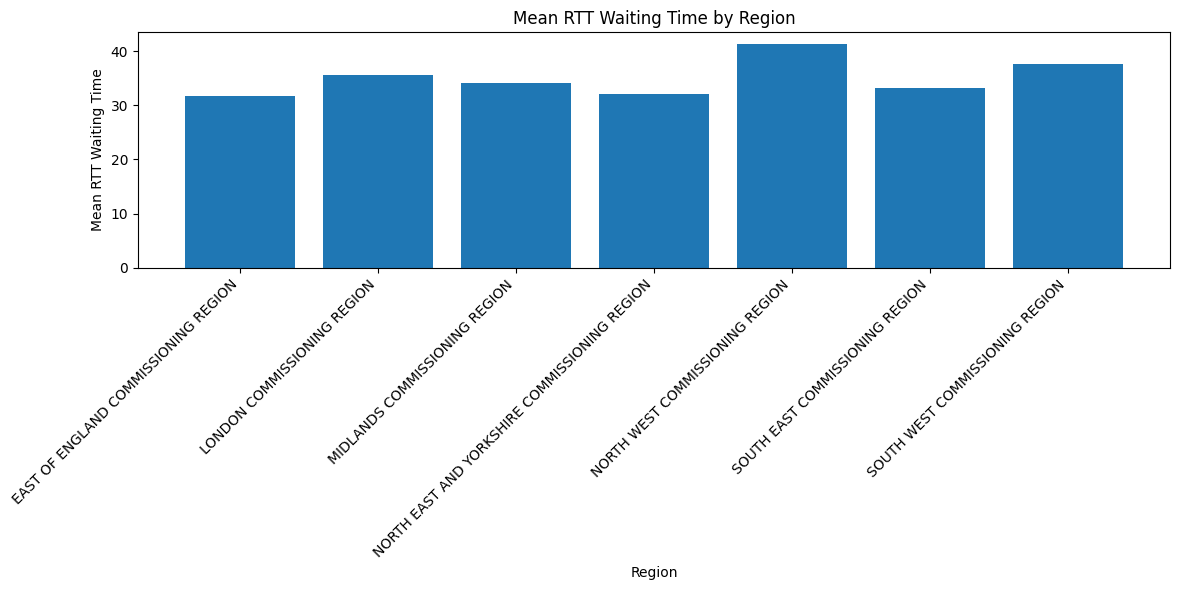

In [47]:
plt.figure(figsize=(12,6))

plt.bar(
    region_summary["OrgName"],
    region_summary["Mean_RTT_Access"]
)

plt.title("Mean RTT Waiting Time by Region")
plt.xlabel("Region")
plt.ylabel("Mean RTT Waiting Time")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [49]:
# ------------------------------------------------
# Remove UNKNOWN and All rows
# ------------------------------------------------

df = df[
    (df["OrgName"] != "UNKNOWN") &
    (df["OrgName"] != "All")
]

In [50]:
# ------------------------------------------------
# Keep only Commissioning Regions
# ------------------------------------------------

df = df[
    df["OrgName"]
    .str.contains(
        "COMMISSIONING REGION",
        case=False,
        na=False
    )
]

In [51]:
# ------------------------------------------------
# Keep only Presenting Complaint rows
# ------------------------------------------------

df = df[
    df["VariableType"]
    .str.contains(
        "Presenting Complaint",
        case=False,
        na=False
    )
]

In [53]:
# ------------------------------------------------
# RTT column
# ------------------------------------------------

rtt_col = "Mean_WaitAccessingServices"

# Convert RTT column to numeric

df[rtt_col] = (
    df[rtt_col]
    .astype(str)
    .str.replace(",", "", regex=False)
)
df[rtt_col] = pd.to_numeric(
    df[rtt_col],
    errors="coerce"
)

In [54]:
# ------------------------------------------------
# Remove missing RTT values
# ------------------------------------------------

df = df.dropna(
    subset=[rtt_col]
)

print("Remaining rows:", df.shape)


Remaining rows: (0, 171)


In [55]:
# ------------------------------------------------
# Group by disorder type
# ------------------------------------------------

disorder_summary = df.groupby(
    "VariableA",
    as_index=False
).agg(
    Mean_RTT=(rtt_col, "mean")
)


In [56]:
# ------------------------------------------------
# Sort values
# ------------------------------------------------

disorder_summary = disorder_summary.sort_values(
    "Mean_RTT",
    ascending=False
)

print(disorder_summary.head(20))

Empty DataFrame
Columns: [VariableA, Mean_RTT]
Index: []


In [60]:
print(disorder_summary.columns.tolist())
print(disorder_summary.head())

['VariableA', 'Mean_RTT']
Empty DataFrame
Columns: [VariableA, Mean_RTT]
Index: []


In [61]:
df[df["VariableType"] == "Presenting Complaint"][
    ["VariableA", "Mean_WaitAccessingServices", "Mean_WaitFinishedCourseTreatment"]
].isna().sum()

VariableA                           0
Mean_WaitAccessingServices          0
Mean_WaitFinishedCourseTreatment    0
dtype: int64

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("psych-ther-ann-rep-csv-2024-25-main2.csv", low_memory=False)

df.columns = df.columns.str.strip()

df = df.replace(["*", "-", "", "NULL", "null", "NaN", "nan"], np.nan)

# Keep only commissioning regions
df = df[
    df["OrgName"].str.contains("COMMISSIONING REGION", case=False, na=False)
].copy()

# Keep only Waiting Time rows
wait_df = df[
    df["VariableType"].str.contains("Waiting Time", case=False, na=False)
].copy()

# Convert waiting columns
wait_cols = [
    "Mean_WaitAccessingServices",
    "Mean_WaitFinishedCourseTreatment"
]

for col in wait_cols:
    wait_df[col] = pd.to_numeric(wait_df[col], errors="coerce")

# Keep Mean wait rows only
mean_wait_df = wait_df[
    wait_df["VariableB"].str.contains("Mean wait", case=False, na=False)
].copy()

print(mean_wait_df[
    ["OrgName", "VariableA", "VariableB", "Mean_WaitAccessingServices", "Mean_WaitFinishedCourseTreatment"]
])

                                             OrgName  \
51329                    LONDON COMMISSIONING REGION   
51336                    LONDON COMMISSIONING REGION   
51595                SOUTH WEST COMMISSIONING REGION   
51602                SOUTH WEST COMMISSIONING REGION   
51861                SOUTH EAST COMMISSIONING REGION   
51868                SOUTH EAST COMMISSIONING REGION   
52127                  MIDLANDS COMMISSIONING REGION   
52134                  MIDLANDS COMMISSIONING REGION   
52393           EAST OF ENGLAND COMMISSIONING REGION   
52400           EAST OF ENGLAND COMMISSIONING REGION   
52659                NORTH WEST COMMISSIONING REGION   
52666                NORTH WEST COMMISSIONING REGION   
52925  NORTH EAST AND YORKSHIRE COMMISSIONING REGION   
52932  NORTH EAST AND YORKSHIRE COMMISSIONING REGION   

                       VariableA  VariableB  Mean_WaitAccessingServices  \
51329         Accessing services  Mean wait                        22.1   
51336  Fi

In [63]:
# Group by waiting type

waiting_summary = mean_wait_df.groupby(
    "VariableA",
    as_index=False
).agg(
    Mean_RTT_Access=("Mean_WaitAccessingServices", "mean"),
    Mean_RTT_Finished=("Mean_WaitFinishedCourseTreatment", "mean")
)

print(waiting_summary)

                   VariableA  Mean_RTT_Access  Mean_RTT_Finished
0         Accessing services             21.5          20.271429
1  First to Second treatment             48.7          68.014286


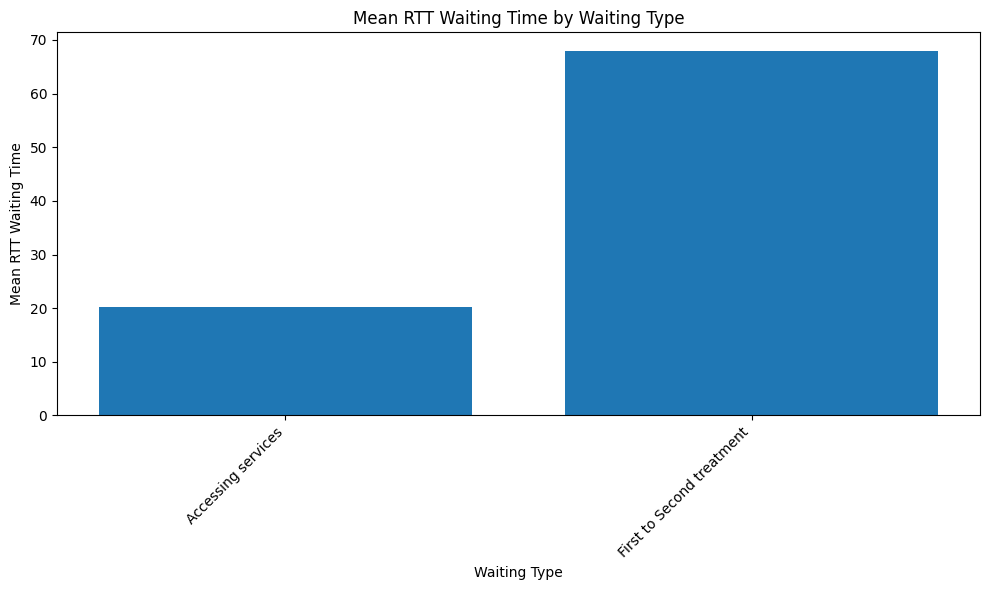

In [64]:
plt.figure(figsize=(10, 6))

plt.bar(
    waiting_summary["VariableA"],
    waiting_summary["Mean_RTT_Finished"]
)

plt.title("Mean RTT Waiting Time by Waiting Type")
plt.xlabel("Waiting Type")
plt.ylabel("Mean RTT Waiting Time")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

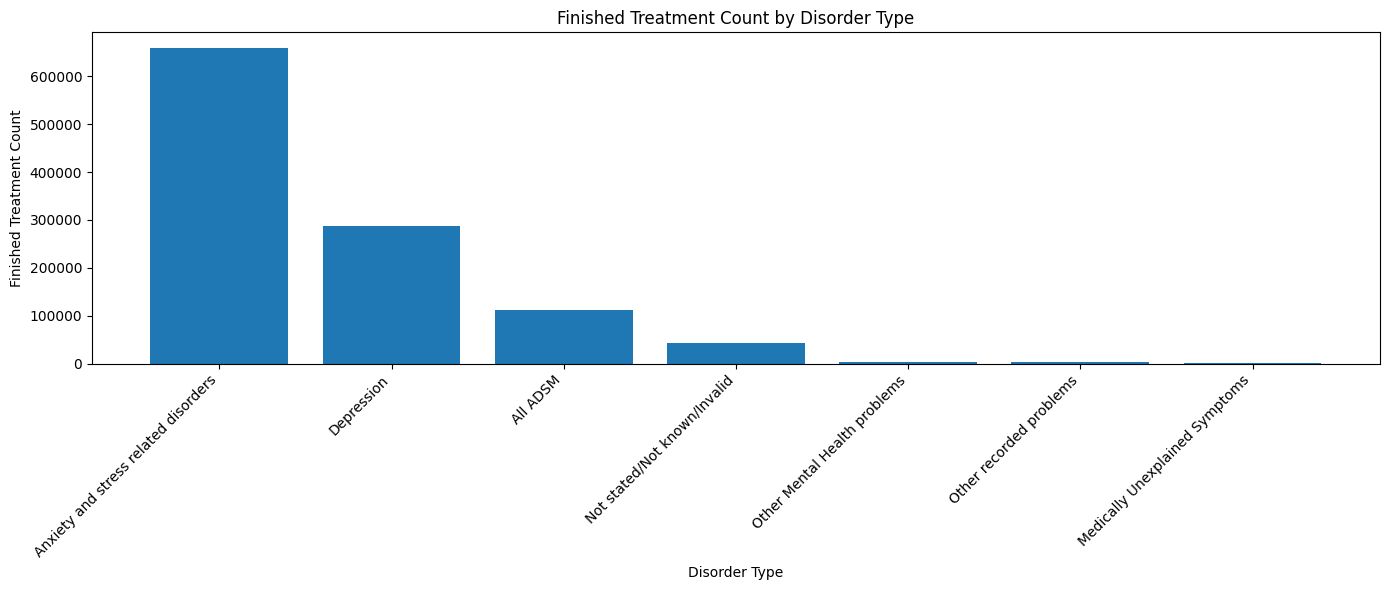

In [65]:
disorder_df = df[
    df["VariableType"].str.contains("Presenting Complaint", case=False, na=False)
].copy()

disorder_df["Count_FinishedCourseTreatment"] = pd.to_numeric(
    disorder_df["Count_FinishedCourseTreatment"],
    errors="coerce"
)

disorder_summary = disorder_df.groupby(
    "VariableA",
    as_index=False
).agg(
    Total_Finished_Treatment=("Count_FinishedCourseTreatment", "sum")
)

disorder_summary = disorder_summary.sort_values(
    "Total_Finished_Treatment",
    ascending=False
)

plt.figure(figsize=(14, 6))

plt.bar(
    disorder_summary["VariableA"],
    disorder_summary["Total_Finished_Treatment"]
)

plt.title("Finished Treatment Count by Disorder Type")
plt.xlabel("Disorder Type")
plt.ylabel("Finished Treatment Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(
    "psych-ther-ann-rep-csv-2024-25-main2.csv",
    low_memory=False
)

df.columns = df.columns.str.strip()

df = df.replace(
    ["*", "-", "", "NULL", "null", "NaN", "nan"],
    np.nan
)

In [67]:
df = df[
    df["OrgName"].str.contains(
        "COMMISSIONING REGION",
        case=False,
        na=False
    )
].copy()

print(df.shape)

(1862, 50)


# CREATE DISORDER DATASET

In [68]:
disorder_df = df[
    df["VariableType"].str.contains(
        "Presenting Complaint",
        case=False,
        na=False
    )
].copy()

print(disorder_df.shape)

(140, 50)


# CONVERT TREATMENT COUNTS

In [69]:
count_col = "Count_FinishedCourseTreatment"

disorder_df[count_col] = pd.to_numeric(
    disorder_df[count_col],
    errors="coerce"
)

disorder_df = disorder_df.dropna(
    subset=[count_col]
)

print(disorder_df[[ "VariableA", count_col ]].head())

                                  VariableA  Count_FinishedCourseTreatment
51278                              All ADSM                        16400.0
51279                            Depression                        50960.0
51280  Anxiety and stress related disorders                        52715.0
51281  Anxiety and stress related disorders                          535.0
51282  Anxiety and stress related disorders                        25635.0


# CREATE RTT DATASET

In [70]:
rtt_df = df.copy()

rtt_col = "Mean_WaitAccessingServices"

rtt_df[rtt_col] = pd.to_numeric(
    rtt_df[rtt_col],
    errors="coerce"
)

rtt_df = rtt_df.dropna(
    subset=[rtt_col]
)

print(rtt_df[[ "OrgName", rtt_col ]].head())

                               OrgName  Mean_WaitAccessingServices
51329      LONDON COMMISSIONING REGION                        22.1
51336      LONDON COMMISSIONING REGION                        49.2
51595  SOUTH WEST COMMISSIONING REGION                        22.1
51602  SOUTH WEST COMMISSIONING REGION                        53.3
51861  SOUTH EAST COMMISSIONING REGION                        19.3


# REGIONAL RTT AVERAGE

In [71]:
region_rtt = rtt_df.groupby(
    "OrgName",
    as_index=False
).agg(
    Regional_Mean_RTT=(rtt_col, "mean")
)

print(region_rtt)

                                         OrgName  Regional_Mean_RTT
0           EAST OF ENGLAND COMMISSIONING REGION              31.70
1                    LONDON COMMISSIONING REGION              35.65
2                  MIDLANDS COMMISSIONING REGION              34.05
3  NORTH EAST AND YORKSHIRE COMMISSIONING REGION              32.05
4                NORTH WEST COMMISSIONING REGION              41.40
5                SOUTH EAST COMMISSIONING REGION              33.15
6                SOUTH WEST COMMISSIONING REGION              37.70


# MERGE DISORDER COUNTS WITH REGION RTT

In [72]:
merged_df = pd.merge(
    disorder_df,
    region_rtt,
    on="OrgName",
    how="left"
)

print(merged_df.head())

                OrgType OrgCode                      OrgName  \
0  Commissioning Region     Y56  LONDON COMMISSIONING REGION   
1  Commissioning Region     Y56  LONDON COMMISSIONING REGION   
2  Commissioning Region     Y56  LONDON COMMISSIONING REGION   
3  Commissioning Region     Y56  LONDON COMMISSIONING REGION   
4  Commissioning Region     Y56  LONDON COMMISSIONING REGION   

           VariableType                             VariableA  \
0  Presenting Complaint                              All ADSM   
1  Presenting Complaint                            Depression   
2  Presenting Complaint  Anxiety and stress related disorders   
3  Presenting Complaint  Anxiety and stress related disorders   
4  Presenting Complaint  Anxiety and stress related disorders   

                      VariableB Count_ReferralsReceived  \
0                         Total                     NaN   
1                           NaN                   76500   
2                           All                

# ESTIMATED RTT BY DISORDER TYPE

In [73]:
disorder_rtt = merged_df.groupby(
    "VariableA",
    as_index=False
).apply(
    lambda x: pd.Series({
        "Estimated_Mean_RTT":
        np.average(
            x["Regional_Mean_RTT"],
            weights=x[count_col]
        )
    })
).reset_index(drop=True)

print(disorder_rtt)

                              VariableA  Estimated_Mean_RTT
0                              All ADSM           34.658630
1  Anxiety and stress related disorders           34.825506
2                            Depression           34.661655
3        Medically Unexplained Symptoms           34.848266
4          Not stated/Not known/Invalid           35.760545
5          Other Mental Health problems           35.094238
6               Other recorded problems           34.835541


C:\Users\rajmu\AppData\Local\Temp\ipykernel_36712\1870370964.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).apply(


# SORT RESULTS

In [74]:
disorder_rtt = disorder_rtt.sort_values(
    "Estimated_Mean_RTT",
    ascending=False
)

print(disorder_rtt.head(20))

                              VariableA  Estimated_Mean_RTT
4          Not stated/Not known/Invalid           35.760545
5          Other Mental Health problems           35.094238
3        Medically Unexplained Symptoms           34.848266
6               Other recorded problems           34.835541
1  Anxiety and stress related disorders           34.825506
2                            Depression           34.661655
0                              All ADSM           34.658630


# PLOT CHART

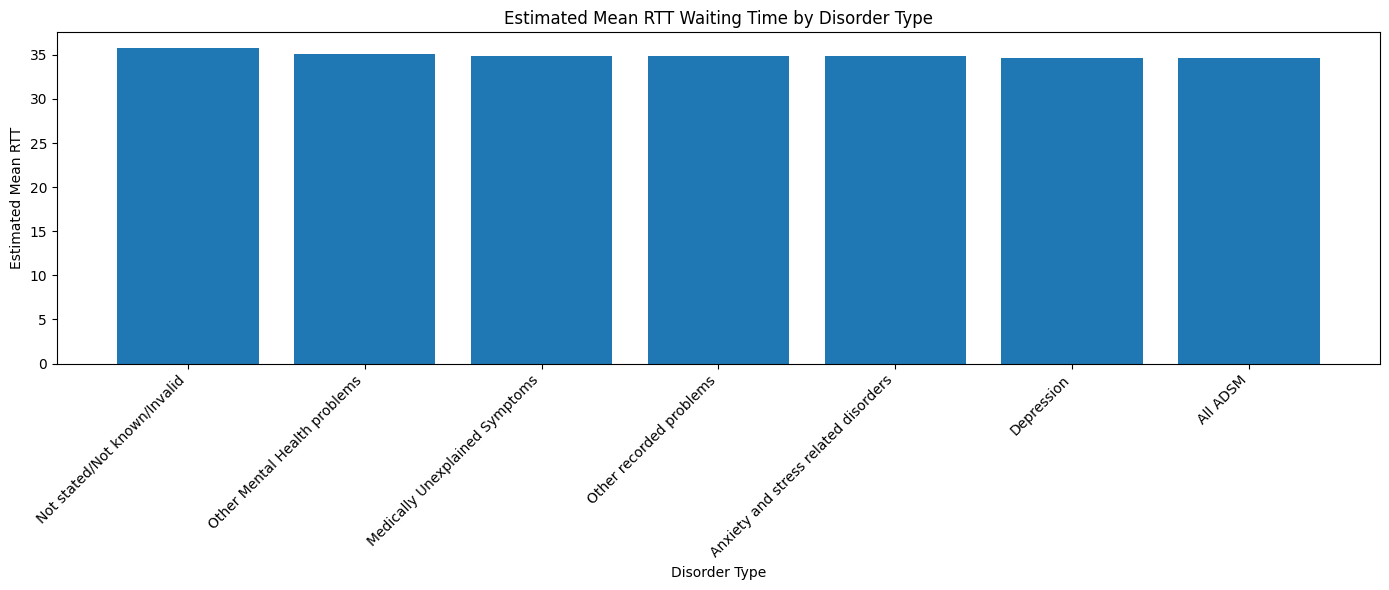

In [75]:
plt.figure(figsize=(14,6))

plt.bar(
    disorder_rtt["VariableA"],
    disorder_rtt["Estimated_Mean_RTT"]
)

plt.title(
    "Estimated Mean RTT Waiting Time by Disorder Type"
)

plt.xlabel("Disorder Type")

plt.ylabel("Estimated Mean RTT")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.savefig(
    "estimated_mean_rtt_by_disorder.png",
    dpi=300
)

plt.show()

In [76]:
disorder_rtt.to_csv(
    "estimated_mean_rtt_by_disorder.csv",
    index=False
)

print("Saved successfully")

Saved successfully
